# keras-hexagdly CNN example

Port of HexagDLy's own `hexagdly_cnn_example.ipynb`: a small CNN classifies hexagonal toy shapes. The API mirrors PyTorch HexagDLy's -- `keras_hexagdly.Conv2d`/`MaxPool2d` are ordinary Keras layers, so the model is an ordinary `keras.Sequential` trained with `model.fit`.

In [1]:
%matplotlib inline
import numpy as np
import keras
import keras_hexagdly as hgly

from toy_data import ToyDataset, toy_hex_image
from hexplot import plot_hextensor, kernel_to_hextensor

2026-06-29 20:41:10.789162: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-29 20:41:10.789405: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-29 20:41:10.820499: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


First, hexagonal image data is created via `ToyDataset`. In this example, hexagonally sampled images with different shapes at random positions are generated. The training and validation sets contain 128 and 32 images of each shape respectively.
Possible shapes: `['small_hexagon', 'medium_hexagon', 'snowflake_1', 'snowflake_2', 'snowflake_3', 'snowflake_4', 'double_hex']`.

In [2]:
shape_list = ['snowflake_2', 'snowflake_3', 'snowflake_4', 'double_hex']
H, W = 20, 20

train_data = ToyDataset(shape_list, 128, H, W).create(seed=0)
val_data = ToyDataset(shape_list, 32, H, W).create(seed=1)
x_train, y_train = train_data.to_arrays()
x_val, y_val = val_data.to_arrays()
print('train:', x_train.shape, ' val:', x_val.shape)

train: (512, 20, 20, 1)  val: (128, 20, 20, 1)


A few example images from the validation set:

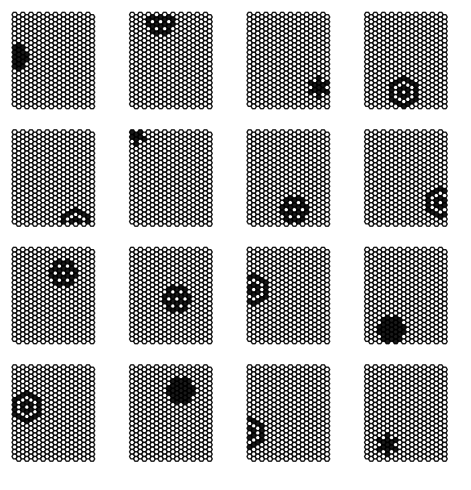

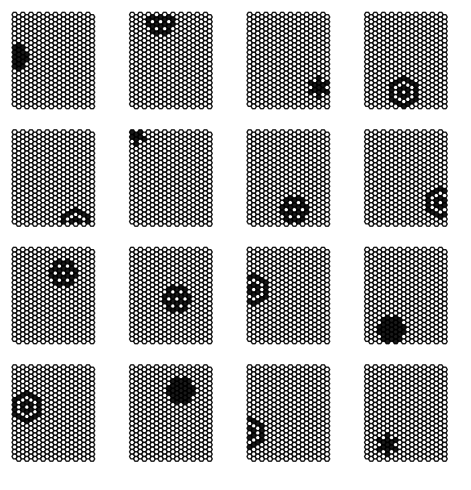

In [3]:
plot_hextensor(x_val[:16], figname='val_examples')

Next, a small CNN is built with `keras_hexagdly`'s convolution and pooling layers -- a plain `keras.Sequential`, just like any other Keras model:

In [ ]:
share_neighbors = True
kernel_size = 2

model = keras.Sequential([
    keras.layers.Input(shape=(H, W, 1)),
    hgly.Conv2d(out_channels=16, kernel_size=kernel_size, stride=1, share_neighbors=share_neighbors),
    keras.layers.ReLU(),
    hgly.MaxPool2d(kernel_size=1, stride=2),
    hgly.Conv2d(out_channels=32, kernel_size=kernel_size, stride=1, share_neighbors=share_neighbors),
    keras.layers.ReLU(),
    hgly.MaxPool2d(kernel_size=1, stride=2),
    keras.layers.Flatten(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(shape_list)),
])
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2d)              │ (None, 20, 20, 16)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 20, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool2d_20 (MaxPool2d)       │ (None, 10, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2d)              │ (None, 10, 10, 32)     │         9,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool2d_21 (MaxPool2d)       │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,844 (140.02 KB)

 Trainable params: 35,844 (140.02 KB)

 Non-trainable params: 0 (0.00 B)

The training and validation data are loaded into the model and the CNN is trained for a few epochs:

In [40]:
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=50, verbose=1)
print('final validation accuracy:', round(history.history['val_accuracy'][-1], 3))

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2754 - loss: 2.0559 - val_accuracy: 0.3750 - val_loss: 1.4192
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4121 - loss: 1.2882 - val_accuracy: 0.4375 - val_loss: 1.2027
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5469 - loss: 1.0785 - val_accuracy: 0.5234 - val_loss: 1.0537
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6484 - loss: 0.8972 - val_accuracy: 0.6797 - val_loss: 0.8519
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7129 - loss: 0.7601 - val_accuracy: 0.6953 - val_loss: 0.7240
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7520 - loss: 0.6328 - val_accuracy: 0.7812 - val_loss: 0.6299
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7832 - loss: 0.5510 - val_accuracy: 0.7969 - val_loss: 0.5563
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8145 - loss: 0.4874 - val_accuracy: 0.8047 - v

Looking at the learning curves, the model clearly learns to distinguish the different shapes:

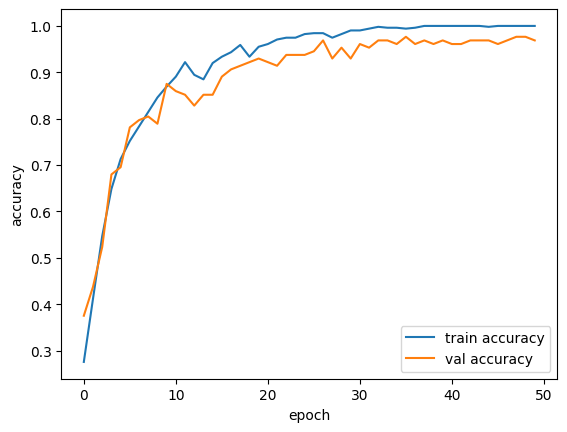

In [41]:
import matplotlib.pyplot as plt
plt.figure('learning_curves')
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend();

To probe the model in detail, a test image is created with a hexagonal shape at a given position. By changing `px`/`py` the shape can be moved to an arbitrary position; the trained CNN's prediction should not depend on it, since the hexagonal convolution preserves translational invariance on the hex grid.

1.    snowflake_3   98.7% <-- correct
2.     double_hex    1.3%
3.    snowflake_4    0.0%
4.    snowflake_2    0.0%


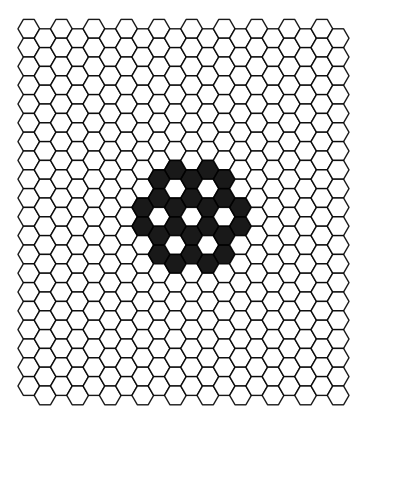

In [42]:
test_shape = 'snowflake_3'
testimage = toy_hex_image(test_shape, H, W, px=10, py=10)
plot_hextensor(testimage, figname='test_shape')

logits = model(keras.ops.convert_to_tensor(testimage))
probs = keras.ops.convert_to_numpy(keras.ops.softmax(logits))[0]
order = np.argsort(-probs)

for rank, idx in enumerate(order):
    tag = ' <-- correct' if shape_list[idx] == test_shape and rank == 0 else ''
    print(f'{rank + 1}. {shape_list[idx]:>14s}  {100 * probs[idx]:5.1f}%{tag}')

Finally, the learned kernels of the first hexagonal convolution can be visualized in their hex layout -- one panel per output channel. `kernel_to_hextensor` adapts to how the layer was built: with `share_neighbors=True` every filter has just one weight per hexagonal ring (centre, the 6 nearest neighbours, the 12 next-nearest), so the panels show concentric rings of uniform shade; with `share_neighbors=False` each cell has its own weight, so the filter is drawn via its impulse response -- a textured hexagonal tile showing how it reacts to a single point input.

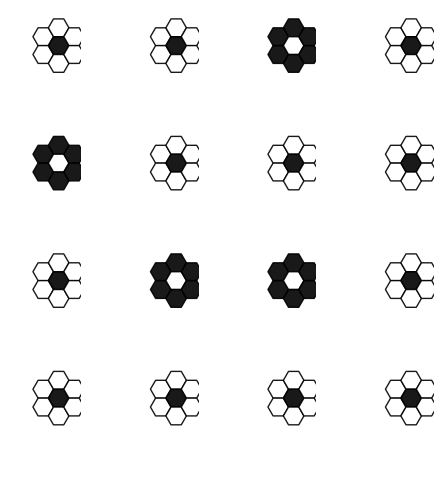

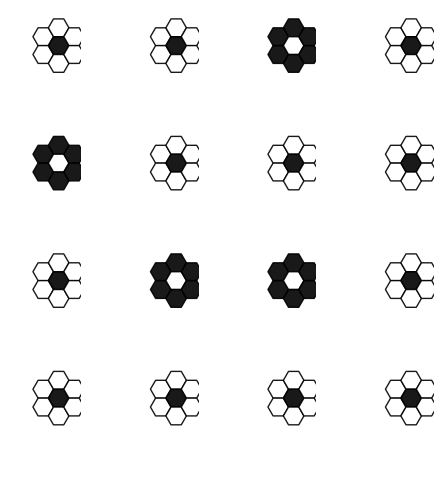

In [43]:
first_conv = model.layers[0]
kernels = kernel_to_hextensor(first_conv)
plot_hextensor(kernels, figname='learned_kernels')